# 1) Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2) import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Read Image

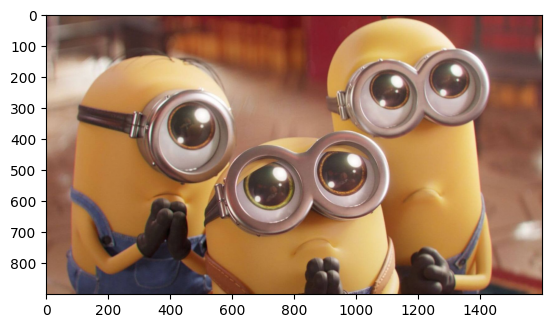

In [3]:
import imageio.v2 as iio
import matplotlib.pyplot as plt

img = iio.imread("/content/drive/MyDrive/ML/computational data mining/تمرین پنجم/minion.jpg")

plt.imshow(img)

In [4]:
print(type(img))

<class 'numpy.ndarray'>


In [5]:
print(np.shape(img))

(900, 1600, 3)


# Adding noise

In [6]:
image_matrix = img.astype(np.float64)
m, n, k = image_matrix.shape

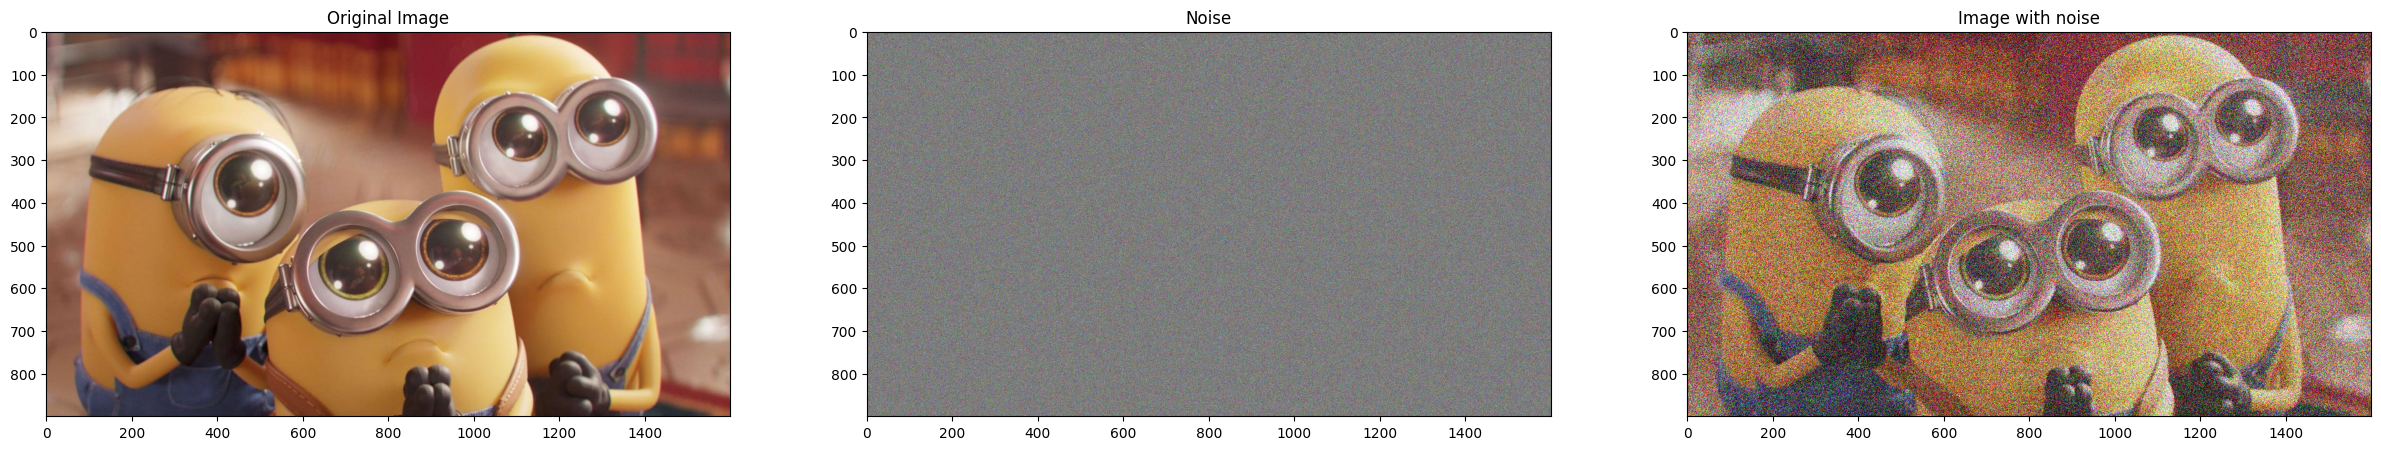

In [8]:
mu, sigma = 0, 100
gaussian_noise = np.random.normal(mu, sigma, (m, n, k))

image_with_noise = (image_matrix + gaussian_noise) / 255

image_with_noise = np.clip(image_with_noise, 0, 1)
# Normalize noise only for visualization
noise_display = (gaussian_noise - gaussian_noise.min()) / (
    gaussian_noise.max() - gaussian_noise.min()
)

fig, ax = plt.subplots(1, 3, figsize=(30, 30))
ax[0].imshow(img)
ax[0].set_title("Original Image")
ax[1].imshow(noise_display)
ax[1].set_title("Noise")
ax[2].imshow(image_with_noise)
ax[2].set_title("Image with noise")
plt.savefig("Images Combined.png", dpi=900)
plt.show()

In [9]:
print(np.shape(img))

(900, 1600, 3)


In [10]:
print(np.shape(gaussian_noise))

(900, 1600, 3)


In [11]:
print(np.shape(image_with_noise))

(900, 1600, 3)


# SVD decomposition of each channel

In [12]:
R_1 = image_with_noise[:, :, 0]
G_1 = image_with_noise[:, :, 1]
B_1 = image_with_noise[:, :, 2]

U_R, s_R, V_R = np.linalg.svd(R_1)
U_G, s_G, V_G = np.linalg.svd(G_1)
U_B, s_B, V_B = np.linalg.svd(B_1)

S_R = np.diag(s_R)
S_G = np.diag(s_G)
S_B = np.diag(s_B)

# Plotting with different K

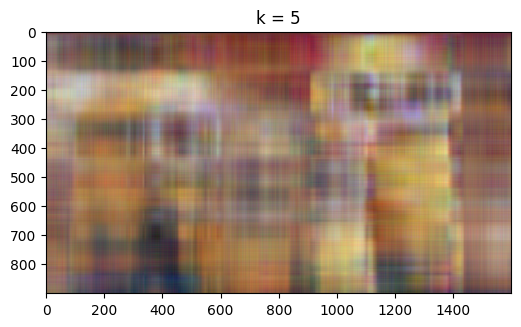

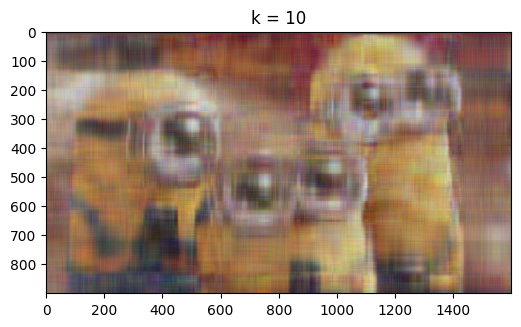

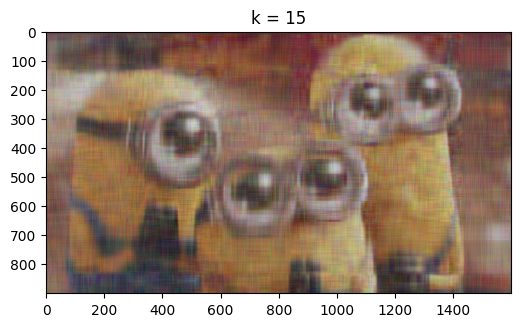

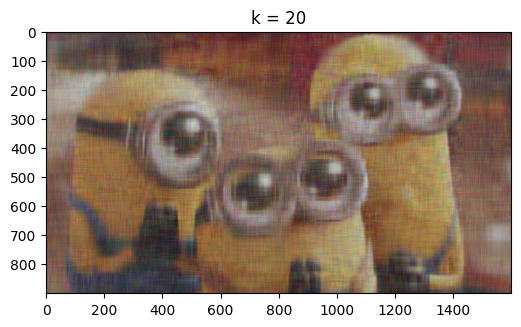

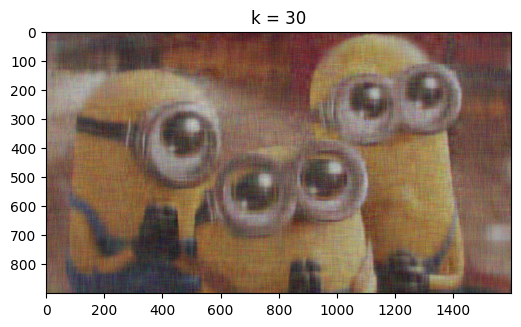

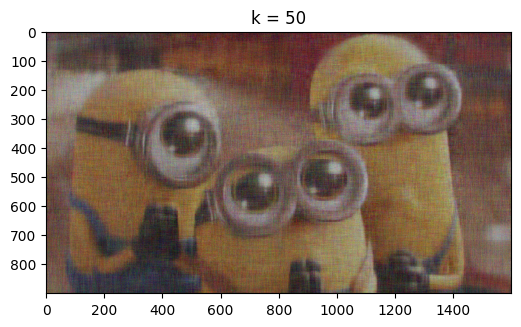

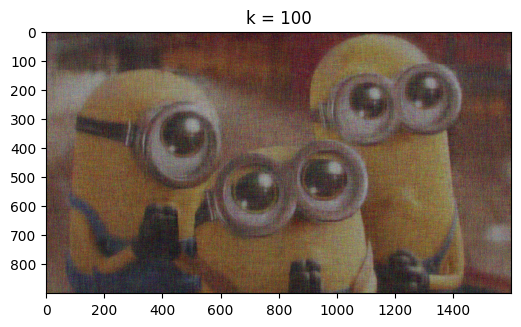

In [15]:
#for r in range(50, 501, 50):
for r in [5, 10, 15, 20, 30, 50, 100]:

    reconstructed_R = np.dot(np.dot(U_R[:,:r], S_R[:r,:r]), V_R[:r,:])
    reconstructed_G = np.dot(np.dot(U_G[:,:r], S_G[:r,:r]), V_G[:r,:])
    reconstructed_B = np.dot(np.dot(U_B[:,:r], S_B[:r,:r]), V_B[:r,:])

    image = np.empty([m, n, k])

    image[:, :, 0] = reconstructed_R
    image[:, :, 1] = reconstructed_G
    image[:, :, 2] = reconstructed_B


    image = image/np.amax(image)
    image = np.clip(image, 0, 1)

    plt.figure(figsize=(6,6))

    plt.imshow(image)


    plt.title(f"k = {r}")
    plt.savefig(f"K = {r}.jpg", dpi=600)


# Plotting the Singular Values - Selecting best K

Text(0.5, 1.0, 'Singular Values for Blue channel')

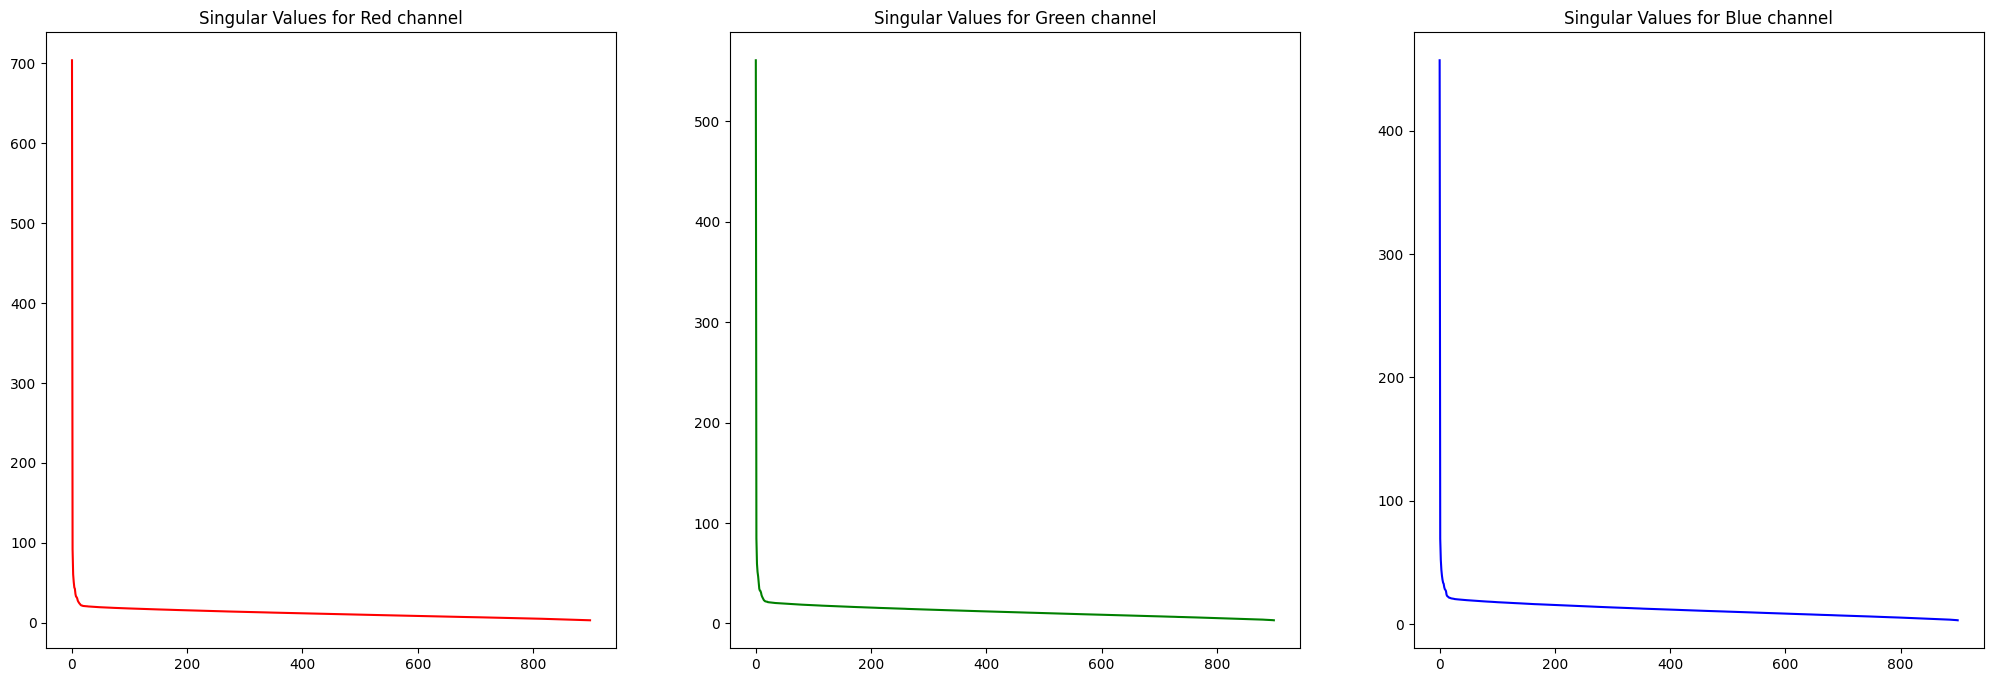

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(25, 8))

ax[0].plot(np.arange(0, s_R.shape[0]), s_R, c="red")
ax[0].set_title("Singular Values for Red channel")

ax[1].plot(np.arange(0, s_G.shape[0]), s_G, c="green")
ax[1].set_title("Singular Values for Green channel")

ax[2].plot(np.arange(0, s_B.shape[0]), s_B, c="blue")
ax[2].set_title("Singular Values for Blue channel")